# LOAN APPROVAL STATUS PREDICTION USING  MACHINE LEARNING

## PROJECT OBJECTIVE 
> - The objective of this project is to built a machine learning classification model predict wheather the loan application will be  approval based on applicant information

## 1 . IMPORT LIBRARIES
> - Import all the reqcuired libraaries for data manupulation , visulaization , preprocessing , model building , evaluation , validation and tunning

In [1]:
# IMPORT LIBRARIE FOR SAVE MODEL
import joblib

# IMPORT THE LIBRARIES FOR VISULAIZATION AND MANUPULATION
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

# IMPORT THE LIBRARIES FOR PREPROCESSING , MODEL BUILDING , EVALUATION , VALIDATION , TUNNING
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import RocCurveDisplay


## 2 . LOAD DATASET
> - load the loan approval dataset into pandas dataframe

In [2]:
data=pd.read_csv("loan_approval_dataset.csv")


## 3 . DATA UNDERSTANDING
> - To understand the each features data type for planning analysis
> - To figure out the shape of the data frame to identify the attributes and records
> - To handle the duplicate records because the model prediction will goes  misleading



In [3]:
data

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [4]:
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


In [6]:
data.shape

(4269, 13)

In [7]:
df=data["loan_id"].duplicated().sum()
df

np.int64(0)

## 4 . DATA CLEANING
> - The data cleaning perform not only in records its also use in attribute
### PROBLEM
> - There dataframe columns name contian some leading space that identify eariler stage  of data understanding
### SOLUTION
> - To solve these problem to use **strip()** function to avoid leading space in the string 

In [8]:
data.columns = data.columns.str.strip()
data_cat = data.select_dtypes(include="str").columns.str.strip()
for col in data_cat:
    data[col] = data[col].str.strip()

## 5 . STATISTICAL ANALYSIS
> - To preform some statictical analysis in numeric data using pandas to get the mean , standard deviation , minimun value , maximum value and precentile of features
### NOTE
> - The statistical anaylysis using pandas only in numerical data in feature frame not considering categorical feature
### PROBLEM 
> - There dataframe contian three categorical  feature
### SOLUTION
> - There selecting the attributes only contianing the categorical data and store in list
> - To figure out the freaquency and unique value of the feature using pandas function **unique()** to solve these prolem


In [9]:
data.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [10]:
data_num = data.select_dtypes(include="int").columns.str.strip()
data_cat = data.select_dtypes(include="str").columns.str.strip()

In [11]:
data_num_list=data_num.to_list()
print("\n",data_cat.to_list())


 ['education', 'self_employed', 'loan_status']


In [12]:
for col in data_cat:
    print(f"categorical data {col}:\n {data[col].unique()}")

categorical data education:
 <StringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str
categorical data self_employed:
 <StringArray>
['No', 'Yes']
Length: 2, dtype: str
categorical data loan_status:
 <StringArray>
['Approved', 'Rejected']
Length: 2, dtype: str


## 6 . EXPLORATORY DATA ANALYSIS
> - The EDA to perform three kind of analysis using imported visulaization libraries :
    > - **univariate analysis**
    > - **bivariate analysis**
    > - **multivariate analysis**

> - before that perform simple analysis using pandas :
    > - **correlation**
    > - **kurtosis**
    > - **skewness**

In [13]:
data.corr(numeric_only=True)

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
loan_id,1.000000,0.005326,0.012592,0.008170,0.009809,0.016323,0.020936,0.018595,-0.000862,0.010765
no_of_dependents,0.005326,1.000000,0.007266,-0.003366,-0.020111,-0.009998,0.007376,-0.001531,0.002817,0.011163
income_annum,0.012592,0.007266,1.000000,0.927470,0.011488,-0.023034,0.636841,0.640328,0.929145,0.851093
loan_amount,0.008170,-0.003366,0.927470,1.000000,0.008437,-0.017035,0.594596,0.603188,0.860914,0.788122
loan_term,0.009809,-0.020111,0.011488,0.008437,1.000000,0.007810,0.008016,-0.005478,0.012490,0.017177
cibil_score,0.016323,-0.009998,-0.023034,-0.017035,0.007810,1.000000,-0.019947,-0.003769,-0.028618,-0.015478
residential_assets_value,0.020936,0.007376,0.636841,0.594596,0.008016,-0.019947,1.000000,0.414786,0.590932,0.527418
commercial_assets_value,0.018595,-0.001531,0.640328,0.603188,-0.005478,-0.003769,0.414786,1.000000,0.591128,0.548576
luxury_assets_value,-0.000862,0.002817,0.929145,0.860914,0.012490,-0.028618,0.590932,0.591128,1.000000,0.788517
bank_asset_value,0.010765,0.011163,0.851093,0.788122,0.017177,-0.015478,0.527418,0.548576,0.788517,1.000000


In [14]:
data.kurt(numeric_only=True)

loan_id                    -1.200000
no_of_dependents           -1.256992
income_annum               -1.182729
loan_amount                -0.743680
loan_term                  -1.220853
cibil_score                -1.185670
residential_assets_value    0.184738
commercial_assets_value     0.100813
luxury_assets_value        -0.738056
bank_asset_value           -0.397277
dtype: float64

In [15]:
data.skew(numeric_only=True)

loan_id                     0.000000
no_of_dependents           -0.017971
income_annum               -0.012814
loan_amount                 0.308724
loan_term                   0.036359
cibil_score                -0.009039
residential_assets_value    0.978451
commercial_assets_value     0.957791
luxury_assets_value         0.322208
bank_asset_value            0.560725
dtype: float64

In [16]:
for col in data.columns:
    print(col)

loan_id
no_of_dependents
education
self_employed
income_annum
loan_amount
loan_term
cibil_score
residential_assets_value
commercial_assets_value
luxury_assets_value
bank_asset_value
loan_status


In [17]:
data.columns = data.columns.str.strip()

### 6.1 . UNIVARIENT ANALYSIS
> - The analysis is used to figure out the distrubution of feature and target
> - This help plainning preprocessing techineque and give proof of outiler present 

In [18]:
discrte_data =["no_of_dependents","loan_term"]

Text(0.5, 1.0, 'status classification')

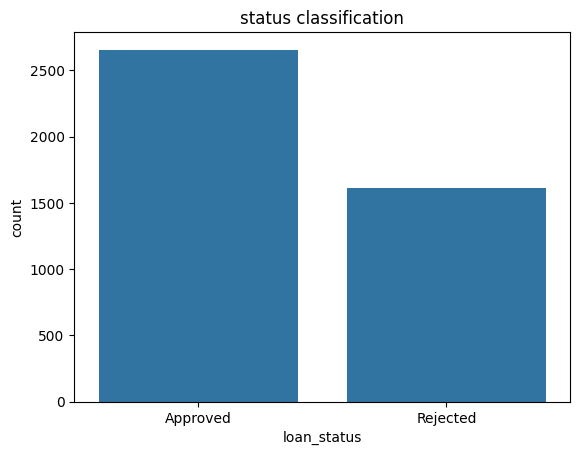

In [19]:
# CLASSIFICATION OF THE CLASS IN TARGET VARIABLE
sns.countplot(x="loan_status",data=data)
plt.title("status classification")

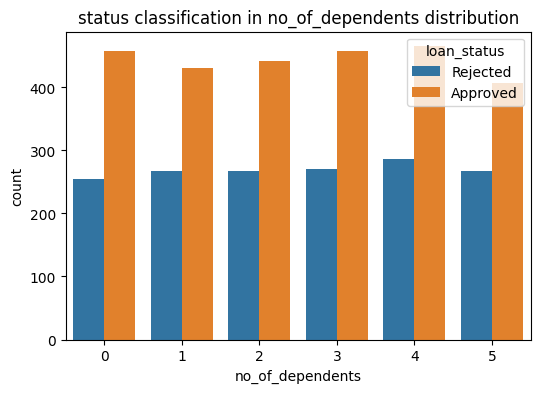

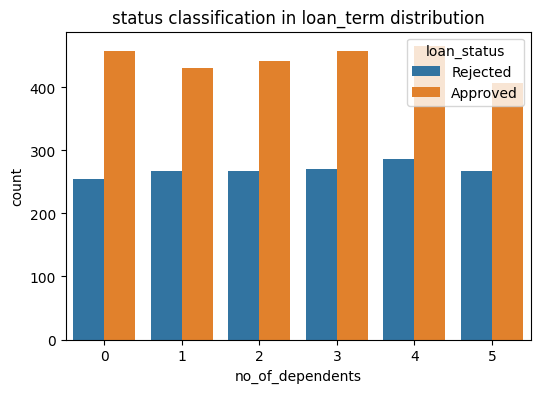

In [20]:
# FREQUENCY OF DISCRTE DATA IN FEATURES 
for col in discrte_data:
    plt.figure(figsize=(6,4))
    sns.countplot(x="no_of_dependents",hue="loan_status",data=data)
    plt.title(f"status classification in {col} distribution")

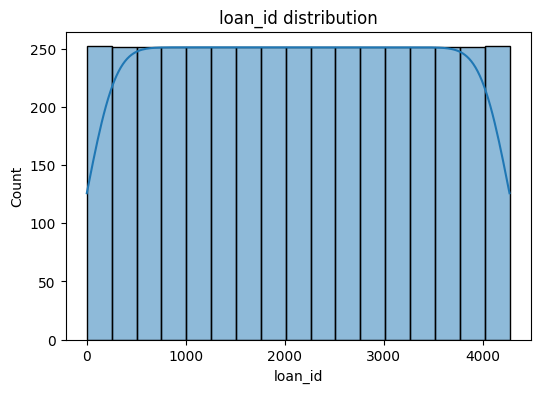

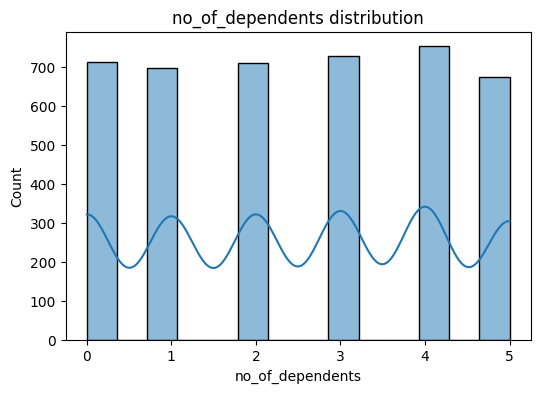

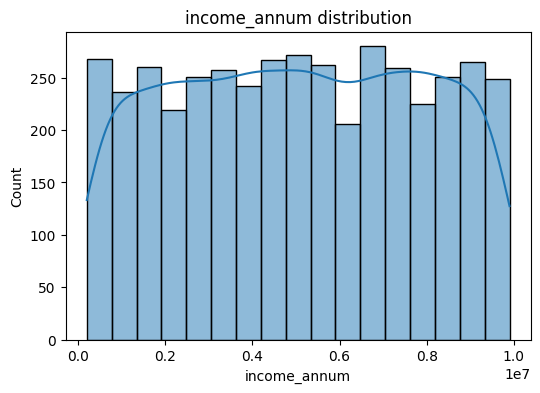

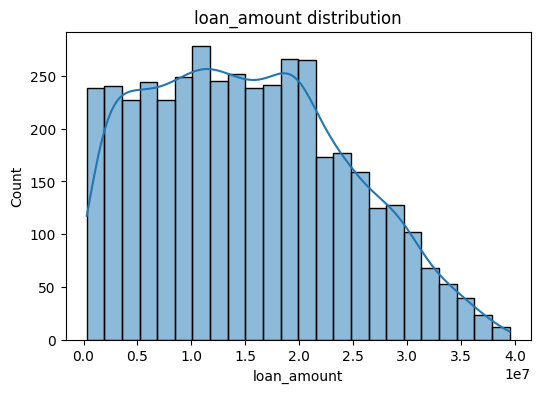

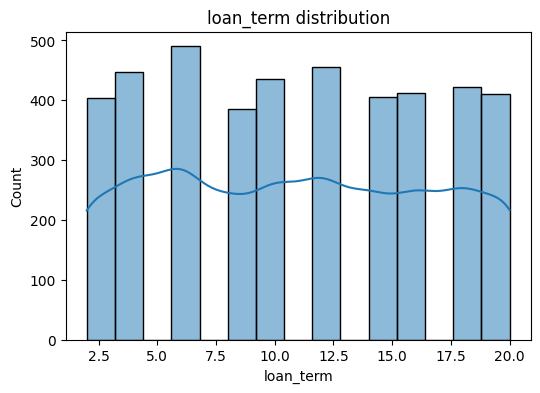

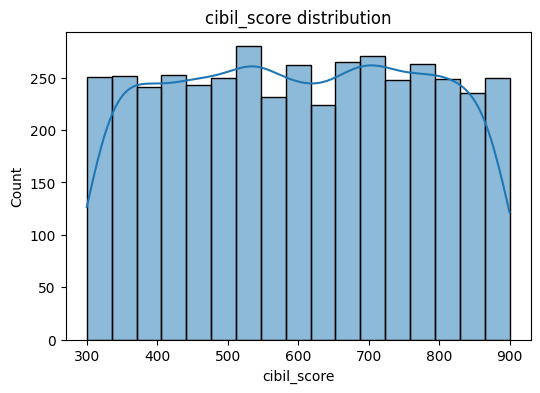

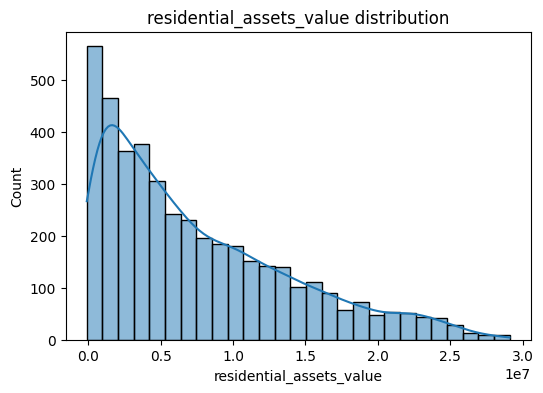

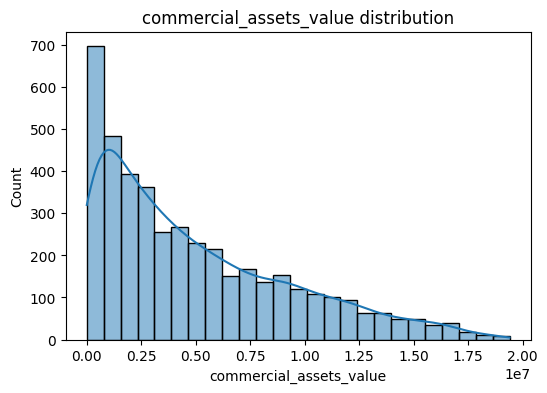

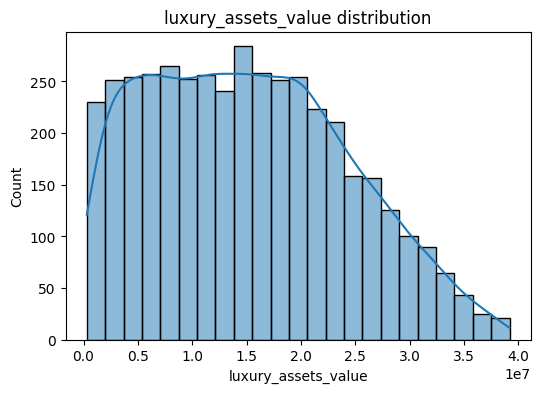

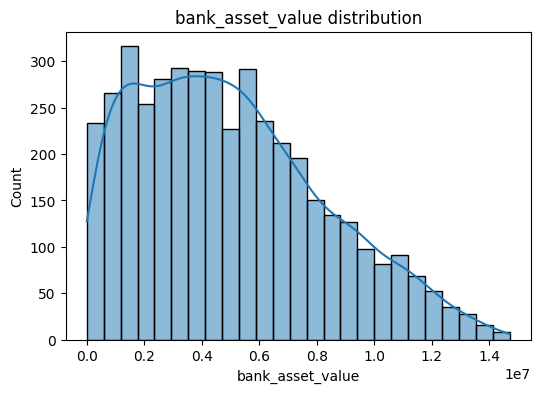

In [21]:
# THE CONTINUOUS VALUE DISRTIBUTION IS HISTOGRAM 
for col in list(data_num):
    plt.figure(figsize=(6,4))
    sns.histplot(x = col ,data= data,kde=True)
    plt.title(f"{col} distribution")
    

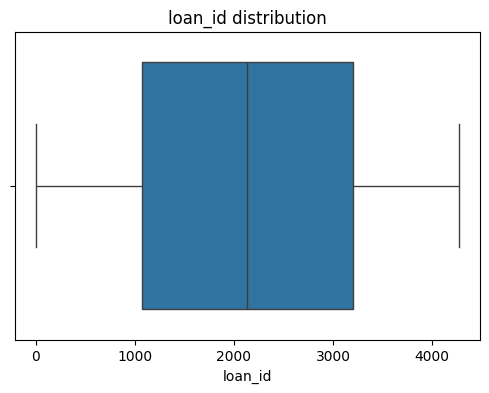

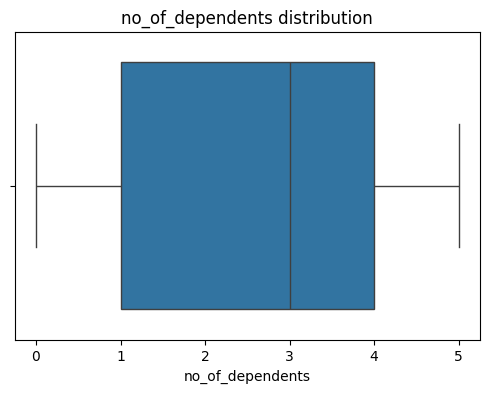

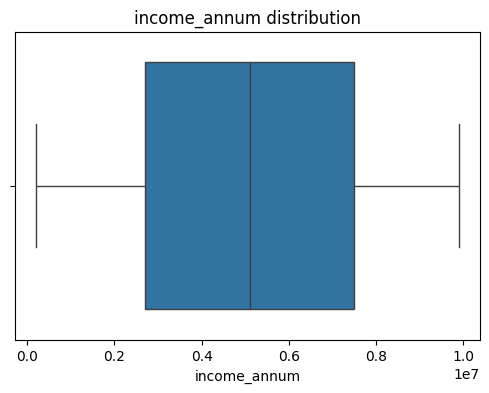

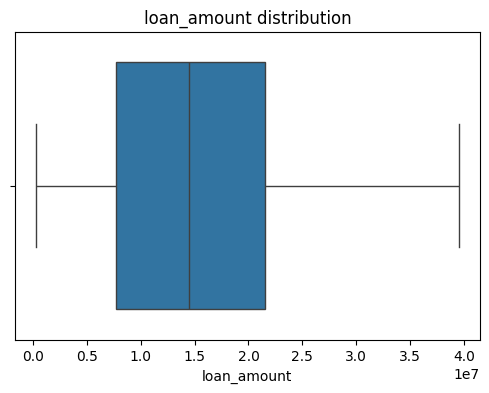

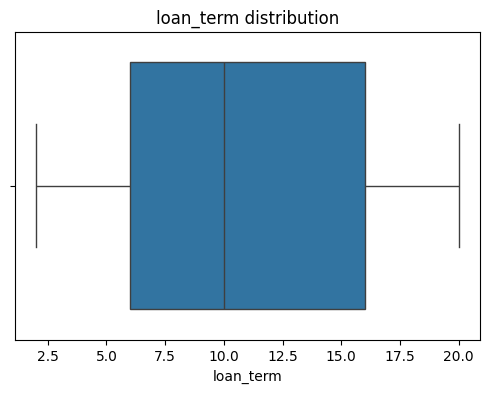

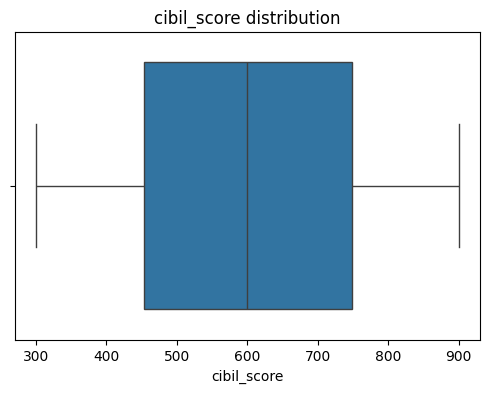

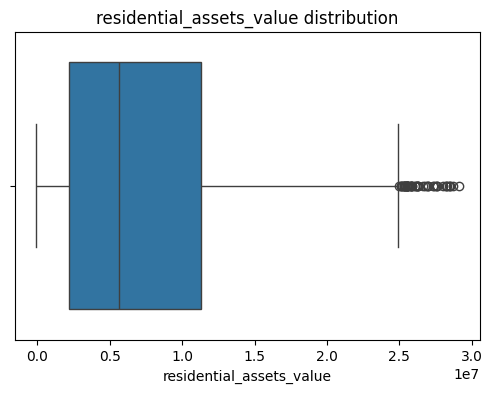

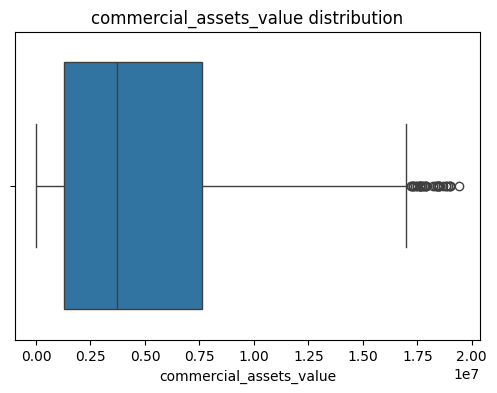

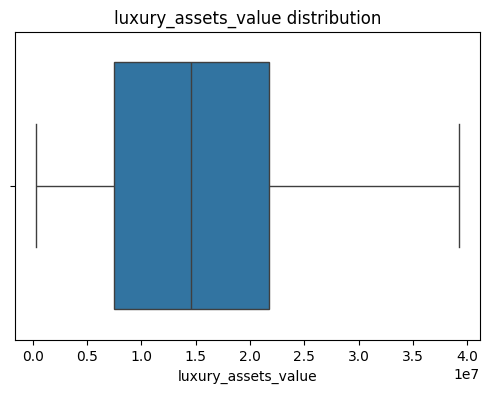

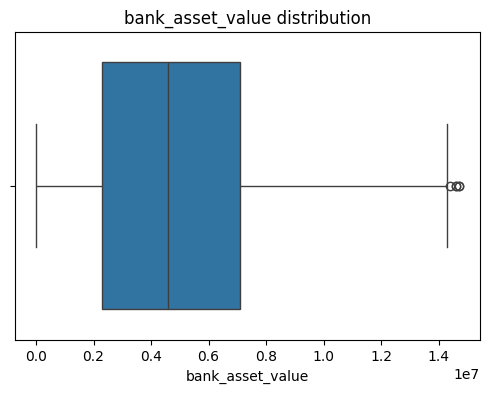

In [22]:
# OUTLIER DETECTION USING BOXPLOT FOR EVIDENCE 
for col in list(data_num):
    plt.figure(figsize=(6,4))
    sns.boxplot(x = col ,data= data)
    plt.title(f"{col} distribution")

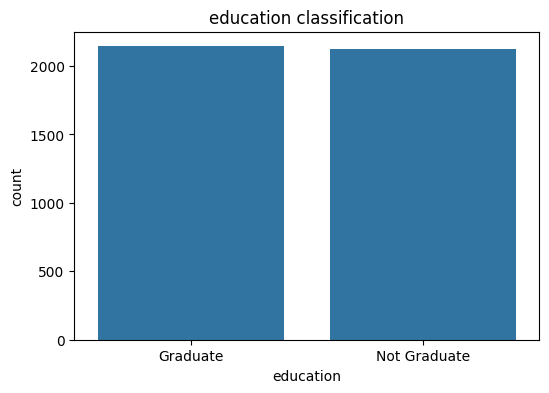

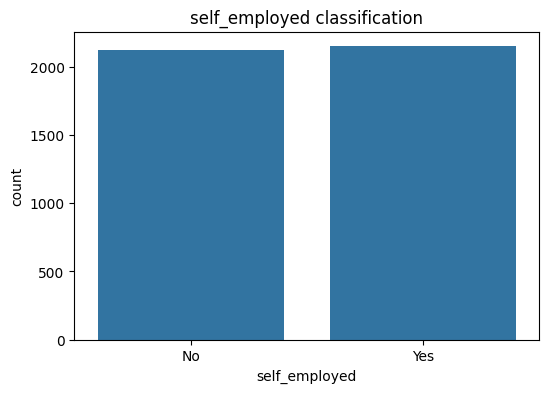

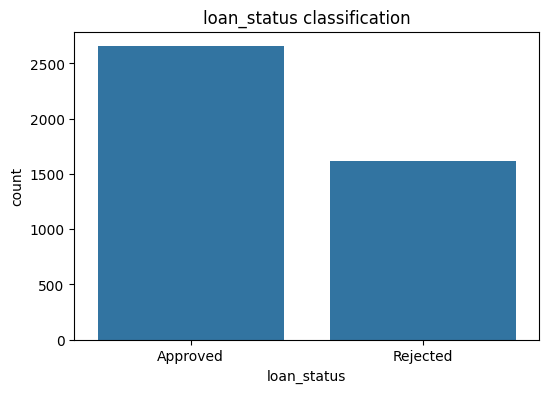

In [23]:
# CLASSIFICATION OF CATEGORICAL DATA 
cat=data_cat.to_list()
for col in cat:
    plt.figure(figsize=(6,4))
    sns.countplot(x = col,data=data)
    plt.title(f"{col} classification")

## 6.2 . BIVARIENT ANALYSIS
> - There going to analysis the numerical feature and categorical feture to target

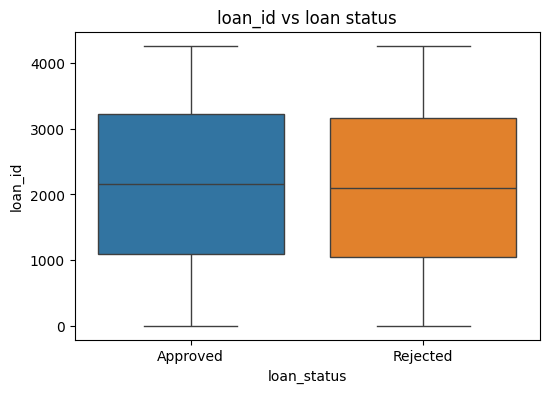

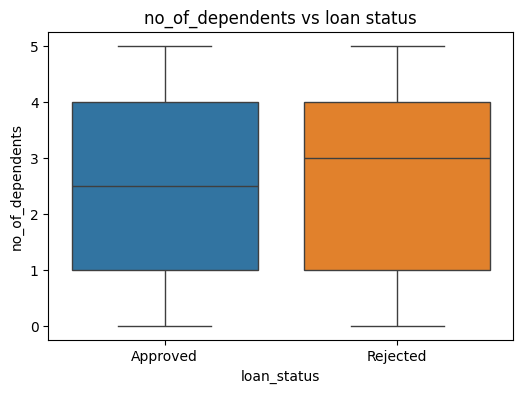

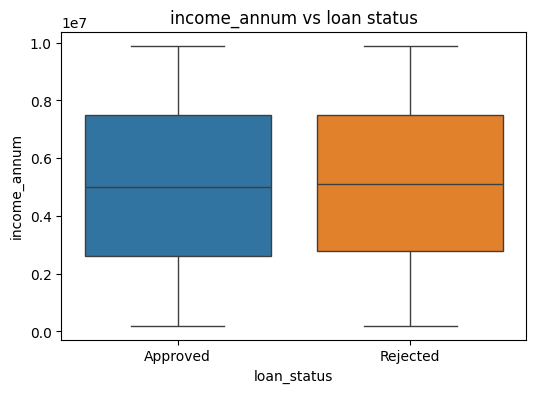

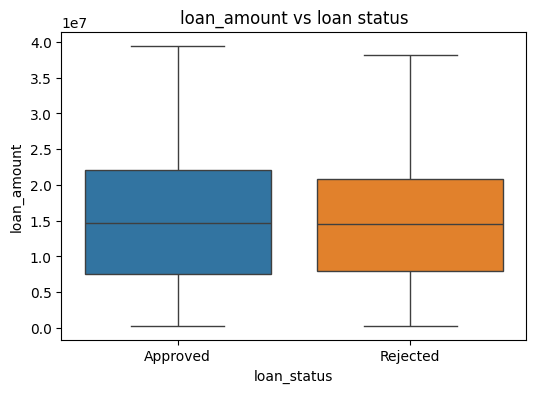

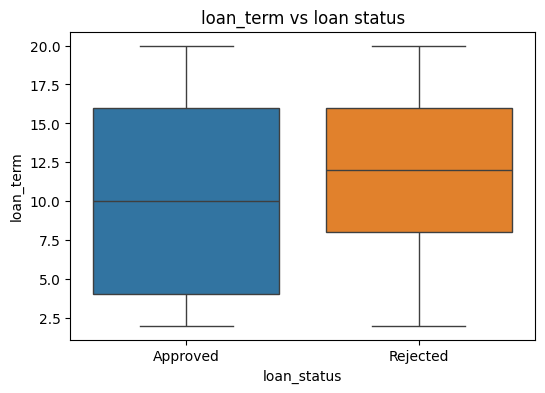

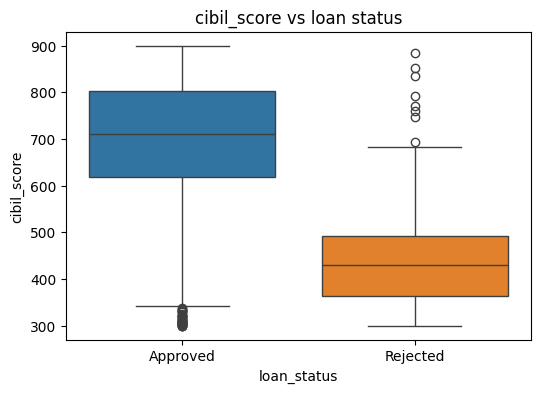

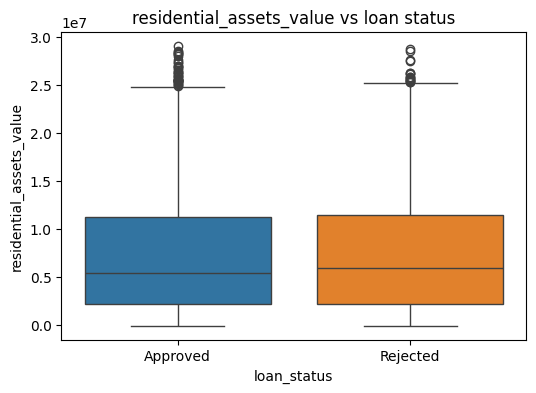

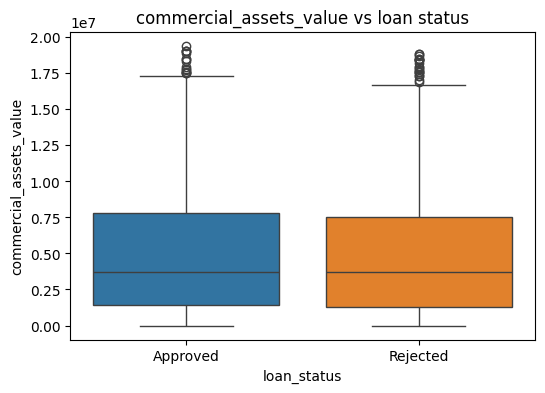

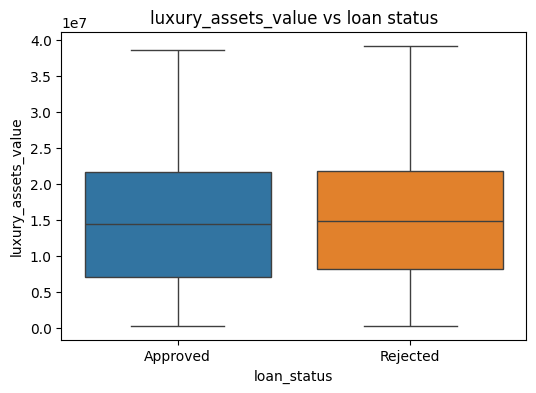

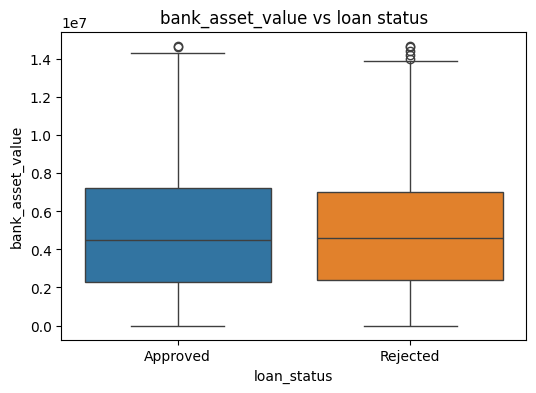

In [24]:
for col in list(data_num):
    plt.figure(figsize=(6,4))
    sns.boxplot(x="loan_status",y=col,hue="loan_status",data=data)
    plt.title(f"{col} vs loan status")

Text(0.5, 1.0, 'loan_term vs loan status')

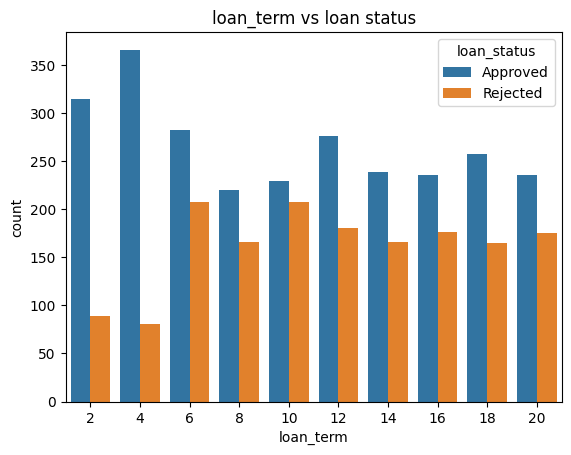

In [25]:
sns.countplot(x="loan_term",hue="loan_status",data=data)
plt.title("loan_term vs loan status")

Text(0.5, 1.0, 'education vs loan status')

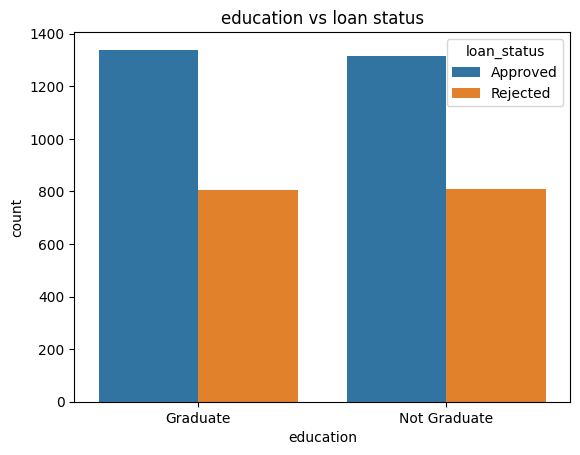

In [26]:
sns.countplot(x="education",hue="loan_status",data=data)
plt.title("education vs loan status")


Text(0.5, 1.0, 'self empolyee vs loan status')

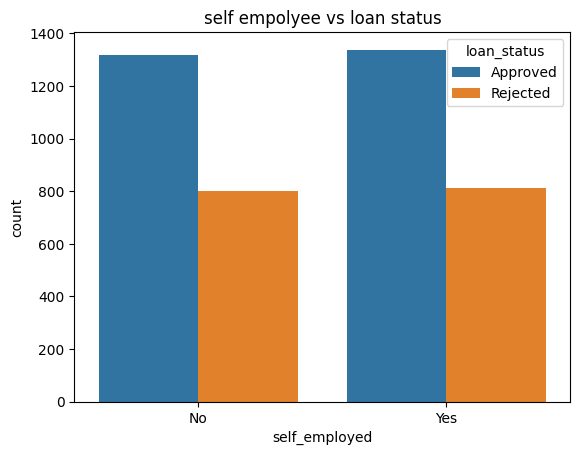

In [27]:
sns.countplot(x="self_employed",hue="loan_status",data=data)
plt.title("self empolyee vs loan status")


## 6.3 . MULTIVARIENT ANALYSIS
> - To find the correlation of feature and target using **heatmap**

Text(0.5, 1.0, 'correlation martix using heatmap')

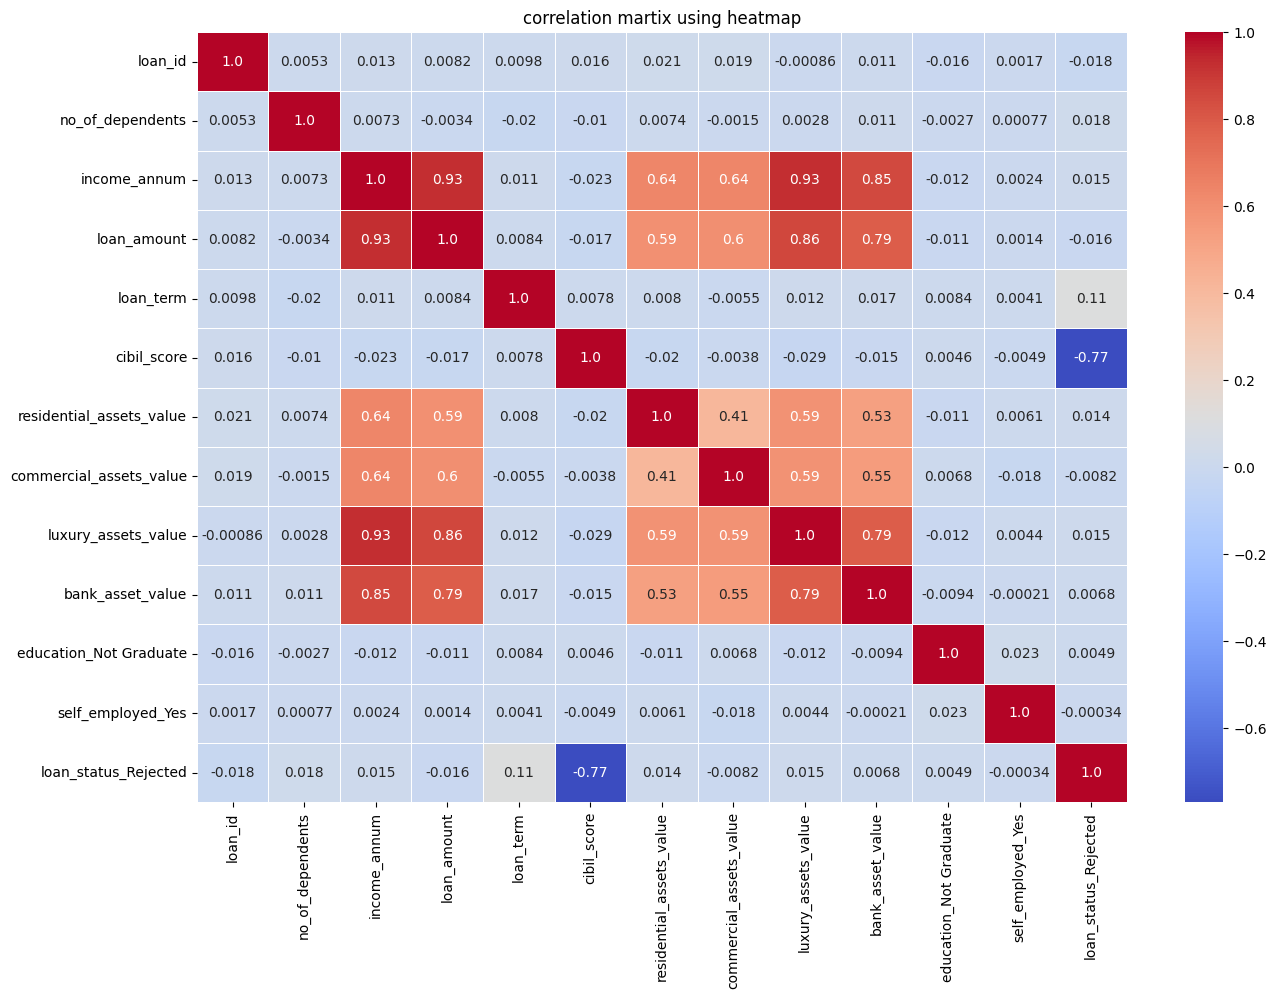

In [28]:
df=pd.get_dummies(data,columns=["education","self_employed","loan_status"],drop_first=True,dtype=int)
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm",fmt=".2",linewidth=0.5)
plt.title("correlation martix using heatmap")

In [29]:
cr=df.corr(numeric_only=True)
cr["loan_status_Rejected"].sort_values(ascending=False)

loan_status_Rejected        1.000000
loan_term                   0.113036
no_of_dependents            0.018114
luxury_assets_value         0.015465
income_annum                0.015189
residential_assets_value    0.014367
bank_asset_value            0.006778
education_Not Graduate      0.004918
self_employed_Yes          -0.000345
commercial_assets_value    -0.008246
loan_amount                -0.016150
loan_id                    -0.017685
cibil_score                -0.770518
Name: loan_status_Rejected, dtype: float64

## 7 . DATASET SPLITTING INTO FEATURES AND TARGET
> - The dataset is split into features and target of preprpcessing and trainnig a model

In [30]:
x=data.drop("loan_status",axis=1)
y=data["loan_status"]

## 8 . FEATURE ENGINEERING
> - There going to perform the  data preprocessing :
    > - Scaling
    > - Encoding
### PROBLEM
> - There some feature have outlier but that not a wrong value its a guine value
> - The logisticregression is affect by outlier its reduce the accuracy of the model
### SOLUTION
> - To solve these problem chosse model like decisiontree and randomforest its handle outlier well  

In [31]:
all_numerical_col= data_num_list
categorical_col=["education","self_employed"]

### 8.1 SCALING ONLY OUTLIER CONTAIN FEATURES

In [32]:
preprocessor=ColumnTransformer(
    transformers=[
        ("num",RobustScaler(),all_numerical_col),
        ("cat",OneHotEncoder(),categorical_col)
        
    ],
    remainder="passthrough"
)

### 8.2 SCALING ALL NUMERICAL FEATURES

In [33]:
preprocessor_scaled=ColumnTransformer(
    transformers=[
        ("num",RobustScaler(),all_numerical_col),
        ("cat",OneHotEncoder(handle_unknown='ignore'),categorical_col)
        
    ],
    remainder="passthrough"
)

### 8.3 ENCODE TARGET VARIABLE

In [34]:
tar_encode=LabelEncoder()
y=tar_encode.fit_transform(y)
print((y==0).sum())


2656


### 8.4 CHECKING CLASS IMBALANCE
> - The classes have slightly imbalanced that fine for classification
> - The better choice use sampling techniques when the classes are highly imbalanced  

In [35]:
data["loan_status"].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

## 9 . TRAIN_TEST_SPLIT
> - The dataset is divided into training and testing sets to evaluate the model on unseen data.

In [36]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.02,random_state=42)


## 10 . MACHINE LEARNING PIPELINE
> - A preprocessing and modeling pipeline is created using ColumnTransformer and Pipeline to ensure consistent data transformation during training and prediction.

In [37]:
pipeline=Pipeline(
    [
        ("preprocessor",preprocessor),
        ("model",LogisticRegression(max_iter=500))
    ])

In [38]:
pipeline_scaled=Pipeline(
    [
        ("preprocessor",preprocessor_scaled),
        ("model",LogisticRegression(max_iter=500))
    ])

## 11 . MODEL TRAINING
> - There bulid two pipeline with difference in  no scaled feature
> - compare the model accuaracy finalize the one pipeline
> - Multiple machine learning algorithms are trained to identify the best-performing classifier for the loan approval prediction task.

In [39]:
model=pipeline.fit(x_train,y_train)

In [40]:
y_pred=model.predict(x_test)

In [41]:
# EVALUATION METRICS FOR MODEL
print("accuracy of model",accuracy_score(y_test,y_pred))
print("precision of model",precision_score(y_test,y_pred))
print("recall of model",recall_score(y_test,y_pred))
print("roc_auc of model",roc_auc_score(y_test,y_pred))
print("f1_score of model",f1_score(y_test,y_pred))

accuracy of model 0.9302325581395349
precision of model 0.875
recall of model 0.9333333333333333
roc_auc of model 0.930952380952381
f1_score of model 0.9032258064516129


In [42]:
model_scaled=pipeline_scaled.fit(x_train,y_train)

In [43]:
y_pred=model_scaled.predict(x_test)

In [44]:
# EVALUATION METRICS FOR SCALED MODEL
print("accuracy of model",accuracy_score(y_test,y_pred))
print("precision of model",precision_score(y_test,y_pred))
print("recall of model",recall_score(y_test,y_pred))
print("roc_auc of model",roc_auc_score(y_test,y_pred))
print("f1_score of model",f1_score(y_test,y_pred))

accuracy of model 0.9302325581395349
precision of model 0.875
recall of model 0.9333333333333333
roc_auc of model 0.930952380952381
f1_score of model 0.9032258064516129


## 11.1 CROSS VALIDATION FOR BEST ONE 
> - Cross-validation is performed to evaluate the model's stability and generalization performance across multiple data splits.

In [45]:
cv_score=cross_val_score(pipeline_scaled,x_train,y_train,cv=5,scoring="roc_auc")
print(f"cv_score : {cv_score}")
print(f"mean of cv_score : {cv_score.mean():.2f}")
print(f"standar deviation of cv_score : {cv_score.std():.2f}")


cv_score : [0.96718636 0.96164766 0.96453531 0.9652629  0.98140823]
mean of cv_score : 0.97
standar deviation of cv_score : 0.01


## 12 . MODEL COMPARISON
> - The **pipeline_scaled** is perform well compare to **pipeline** and using that going to compare model to choose best one

In [46]:
models={
    "logisticregression":Pipeline([
        ("preprocessor",preprocessor_scaled),
        ("model",LogisticRegression(max_iter=1000,random_state=42))
    ]),
    "diceisiontree":Pipeline([
        ("preprocessor",preprocessor_scaled),
        ("model",DecisionTreeClassifier(random_state=42))
    ]),
    "randomforestclassifier":Pipeline([
        ("preprocessor",preprocessor_scaled),
        ("model",RandomForestClassifier(random_state=42))
    ]),
    "knn":Pipeline([
        ("preprocessor",preprocessor_scaled),
        ("model",KNeighborsClassifier())
    ]),
    "navibayes":Pipeline([
        ("preprocessor",preprocessor_scaled),
        ("model",GaussianNB())
    ]),
    "svm":Pipeline([
        ("preprocessor",preprocessor_scaled),
        ("model",SVC(probability=True,random_state=42))
    ])
}

In [47]:
model_results=[]
for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    y_prob=model.predict_proba(x_test)[:,1]
    x_train_accuracy=model.score(x_train,y_train)
    x_test_accuracy=model.score(x_test,y_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    f1_scores=f1_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    roc_auc=roc_auc_score(y_test,y_prob)
    cv_scores=cross_val_score(model,x_train,y_train,cv=5,scoring="roc_auc")
    model_results.append([name,x_train_accuracy,x_test_accuracy,cv_scores.mean(),cv_scores.std(),accuracy,precision,f1_scores,recall,roc_auc])
    
    

In [48]:
models_data=pd.DataFrame(model_results,columns=["NAME","X-TRAIN-ACCURACY","X-TEST-ACCURACY","CV-MEAN","CV-STD","ACCURACY","PRECISION","F1-SCORE","RECALL","ROC-AUC"])
models_data

,NAME,X-TRAIN-ACCURACY,X-TEST-ACCURACY,CV-MEAN,CV-STD,ACCURACY,PRECISION,F1-SCORE,RECALL,ROC-AUC
0,logisticregression,0.918958,0.930233,0.968008,0.006932,0.930233,0.875000,0.903226,0.933333,0.980357
1,diceisiontree,1.000000,0.988372,0.976244,0.002449,0.988372,0.967742,0.983607,1.000000,0.991071
2,randomforestclassifier,1.000000,0.965116,0.997161,0.000957,0.965116,0.909091,0.952381,1.000000,1.000000
3,knn,0.927803,0.837209,0.941157,0.008629,0.837209,0.722222,0.787879,0.866667,0.899107
4,navibayes,0.934736,0.906977,0.967008,0.006952,0.906977,0.823529,0.875000,0.933333,0.972024
5,svm,0.950753,0.930233,0.978380,0.004672,0.930233,0.875000,0.903226,0.933333,0.989286


## 13 . FINAL MODEL SELECTION 
> - There two model perform well so  compare the top two model
    > - **DECISION TREE**
    > - **RANDOM FOREST**

In [49]:
pipeline_dt=Pipeline([
    ("preprocessor",preprocessor_scaled),
    ("model",DecisionTreeClassifier(random_state=42))
])
pipeline_rf=Pipeline([
    ("preprocessor",preprocessor_scaled),
    ("model",RandomForestClassifier())
])

### 13.1 HYPERPARAMETER TUNING 
> - GridSearchCV is used to identify the optimal hyperparameters for the best-performing models.
> - Both model have severval parameter the best parameter its may help to improve the model performance

In [50]:
param_grid_dt={
    "model__max_depth":[3,5,10,None],
    "model__min_samples_split":[2,5,10],
    "model__min_samples_leaf":[1,2,4],
    "model__criterion":["gini","entropy","log_loss"]
}
param_grid_rf={
    "model__n_estimators":[100,200,300],
    "model__max_depth":[5,10,20,None],
    "model__min_samples_split":[2,5,10],
    "model__min_samples_leaf":[1,2,4],
    "model__max_features":["sqrt","log2"]
}

In [51]:
grid_dt=GridSearchCV(
    estimator=pipeline_dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_rf=GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring="f1",
    n_jobs=-1
)


In [52]:
final_model_result=[]
model_dt=grid_dt.fit(x_train,y_train)
name_dt="DECISION TREE"
y_pred_dt=model_dt.predict(x_test)
y_prob_dt=model.predict_proba(x_test)[:,1]
x_train_accuracy_dt=model_dt.score(x_train,y_train)
x_test_accuracy_dt=model_dt.score(x_test,y_test)
accuracy_dt=accuracy_score(y_test,y_pred_dt)
precision_dt=precision_score(y_test,y_pred_dt)
recall_dt=recall_score(y_test,y_pred_dt)
f1_dt=f1_score(y_test,y_pred_dt)
roc_auc_dt=roc_auc_score(y_test,y_prob_dt)
cv_scores_dt=cross_val_score(model_dt,x_train,y_train,cv=5,scoring="f1")
mean_cv_dt=cv_scores_dt.mean()
std_cv_dt=cv_scores_dt.std()
final_model_result.append([name_dt,x_train_accuracy_dt,x_test_accuracy_dt,mean_cv_dt,std_cv_dt,accuracy_dt,precision_dt,recall_dt,f1_dt,roc_auc_dt])

In [53]:
model_rf=grid_rf.fit(x_train,y_train)
name_rf="RANDOM FOREST"
y_pred_rf=model_rf.predict(x_test)
y_prob_rf=model_rf.predict_proba(x_test)[:,1]
x_train_accuracy_rf=model_rf.score(x_train,y_train)
x_test_accuracy_rf=model_rf.score(x_test,y_test)
accuracy_rf=accuracy_score(y_test,y_pred_rf)
precision_rf=precision_score(y_test,y_pred_rf)
recall_rf=recall_score(y_test,y_pred_rf)
f1_rf=f1_score(y_test,y_pred_rf)
roc_auc_rf=roc_auc_score(y_test,y_prob_rf)
cv_scores_rf=cross_val_score(model_rf,x_train,y_train,cv=5,scoring="f1")
final_model_result.append([name_rf,x_train_accuracy_rf,x_test_accuracy_rf,cv_scores_rf.mean(),cv_scores.std(),accuracy_rf,precision_rf,recall_rf,f1_rf,roc_auc_rf])

                             


In [54]:
final_model_data=pd.DataFrame(final_model_result,columns=["NAME","X-TRAIN-ACCURACY","X-TEST-ACCURACY","CV-MEAN","CV-STD","ACCURACY","PRECISION","RECALL","F1-SCORE","ROC-AUC"])
final_model_data_new=pd.concat([models_data,final_model_data],axis=0,ignore_index=True)
final_model_data_new

,NAME,X-TRAIN-ACCURACY,X-TEST-ACCURACY,CV-MEAN,CV-STD,ACCURACY,PRECISION,F1-SCORE,RECALL,ROC-AUC
0,logisticregression,0.918958,0.930233,0.968008,0.006932,0.930233,0.875000,0.903226,0.933333,0.980357
1,diceisiontree,1.000000,0.988372,0.976244,0.002449,0.988372,0.967742,0.983607,1.000000,0.991071
2,randomforestclassifier,1.000000,0.965116,0.997161,0.000957,0.965116,0.909091,0.952381,1.000000,1.000000
3,knn,0.927803,0.837209,0.941157,0.008629,0.837209,0.722222,0.787879,0.866667,0.899107
4,navibayes,0.934736,0.906977,0.967008,0.006952,0.906977,0.823529,0.875000,0.933333,0.972024
5,svm,0.950753,0.930233,0.978380,0.004672,0.930233,0.875000,0.903226,0.933333,0.989286
6,DECISION TREE,0.997790,0.983607,0.969301,0.004663,0.988372,0.967742,0.983607,1.000000,0.989286
7,RANDOM FOREST,0.996195,0.967742,0.969188,0.004672,0.976744,0.937500,0.967742,1.000000,1.000000


### 13.2 BEST HYPERPARAMETERS

In [55]:
print(grid_dt.best_params_)
print(grid_dt.best_score_)

{'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}
0.9745751824123945


## 14 .CONFUSION MATRIX AND CLASSIFICATION REPORTS 
> - The confusion matrix summarizes the model's classification performance by showing correct and incorrect predictions.
> - The classification report provides Precision, Recall, F1-score, and Support for each class.

In [56]:
confusion_matrix_dt=confusion_matrix(y_test,y_pred_dt)
confusion_matrix_rf=confusion_matrix(y_test,y_pred_rf)
classification_report_dt=classification_report(y_test,y_pred_dt)
classification_report_rf=classification_report(y_test,y_pred_rf)


In [57]:
print("confusioin matrix :\n ",confusion_matrix_dt)
print("classification report :\n",classification_report_dt)

confusioin matrix :
  [[55  1]
 [ 0 30]]
classification report :
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        56
           1       0.97      1.00      0.98        30

    accuracy                           0.99        86
   macro avg       0.98      0.99      0.99        86
weighted avg       0.99      0.99      0.99        86



In [58]:
print("confusioin matrix :\n ",confusion_matrix_rf)
print("classification report :\n",classification_report_rf)

confusioin matrix :
  [[54  2]
 [ 0 30]]
classification report :
               precision    recall  f1-score   support

           0       1.00      0.96      0.98        56
           1       0.94      1.00      0.97        30

    accuracy                           0.98        86
   macro avg       0.97      0.98      0.97        86
weighted avg       0.98      0.98      0.98        86



## 15 . ROC CURVE
> - The Receiver Operating Characteristic (ROC) curve illustrates the model's ability to distinguish between approved and rejected loan applications across different classification thresholds.

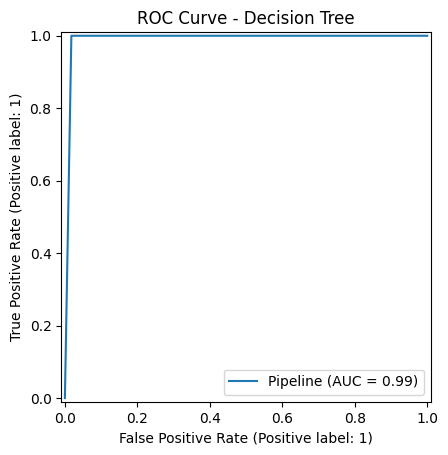

In [59]:
final_model=models["diceisiontree"]
RocCurveDisplay.from_estimator(
    final_model,
    x_test,
    y_test
)

plt.title("ROC Curve - Decision Tree")
plt.show()

## 16 . FEATURE IMPORTANCE
> - Feature importance is analyzed to identify the variables that contribute most to the model's predictions.

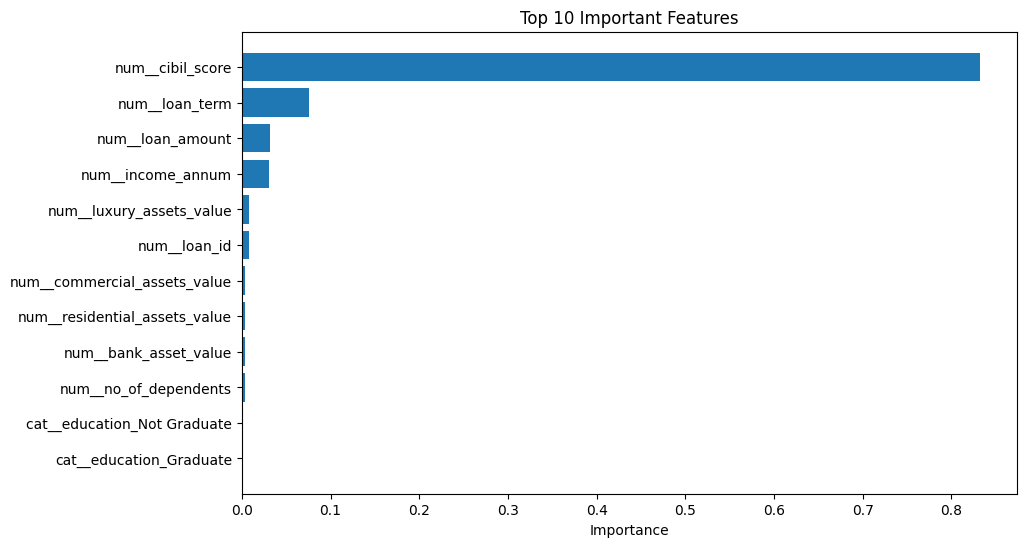

In [60]:
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

importance = final_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:12],
    feature_importance["Importance"][:12]
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

## 17 . MODEL SAVING
> - The final trained pipeline is saved using Joblib for future predictions without retraining the model.

In [61]:
final_model=models["diceisiontree"]
final_model.fit(x_train,y_train)
joblib.dump(final_model,"loan_approval_predictor.pkl")

['loan_approval_predictor.pkl']

## 18 . PREDICTION ON NEW DATA
> - The prediction of output is given as **0** and **1**
    > - **0** is represent the **Approval**
    > - **1** is represent the **Rejection**

In [62]:
model = joblib.load("loan_approval_predictor.pkl")

# Example new applicant
new_data = pd.DataFrame({
    "loan_id": [12345],
    "no_of_dependents": [2],
    "education": ["Graduate"],
    "self_employed": ["No"],
    "income_annum": [600000],
    "loan_amount": [2500000],
    "loan_term": [15],
    "cibil_score": [780],
    "residential_assets_value": [500000],
    "commercial_assets_value": [0],
    "luxury_assets_value": [200000],
    "bank_asset_value": [300000]
})

prediction = model.predict(new_data)

print("Predicted Loan Status:", prediction[0])

Predicted Loan Status: 0


# 19 . PROJECT CONCLUSION

## Problem Statement

The objective of this project is to predict whether a loan application will be approved based on applicant details.

---

## Workflow

- Data Collection
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Train-Test Split
- Preprocessing using ColumnTransformer
- Pipeline Construction
- Model Training
- Model Comparison
- Cross Validation
- Hyperparameter Tuning
- Final Model Evaluation

---

## Models Evaluated

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors
- Naive Bayes
- Support Vector Machine

---

## Final Selected Model

Decision Tree Classifier

---

## Final Performance

Accuracy : 98.84%

Precision : 96.77%

Recall : 100%

F1-score : 98.36%

ROC-AUC : 98.93%

---

### Future Scope

- Deploy the trained model using Streamlit or Flask.
- Use a larger dataset to improve generalization.
- Experiment with ensemble boosting algorithms such as XGBoost or LightGBM.

---

## Conclusion

Among all evaluated models, the Decision Tree classifier achieved the best balance between accuracy, precision, recall, and F1-score. Hyperparameter tuning was performed using GridSearchCV; however, the baseline Decision Tree slightly outperformed the tuned version on the test set. Therefore, the baseline Decision Tree was selected as the final model for deployment.

The trained pipeline was saved using Joblib for future predictions.